# Category prediction (using Anchor similarity)

**Goal:** Predict to which category, each blurb should be placed into (groundtruth is the *category.parent_name* feature)
**Technique used:** 2-level Anchor similarity. For each category and then sub-category, we compute an anchor using average embedding of the blurb from the training set, we then compute the cosine similarity of each blurb with each anchor and select the category with the highest similarity. 

In [ ]:
import os
from tqdm.auto import tqdm
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


## Load data

In [40]:
df = pd.read_csv("./data/dataset.csv")
df.shape

(110161, 16)

In [41]:
df["category.parent_name"].unique()

<StringArray>
[        'Food', 'Film & Video',  'Photography',   'Publishing',
          'Art',       'Comics',        'Music',        'Games',
        'Dance',       'Crafts',            nan,   'Technology',
      'Theater',      'Fashion',   'Journalism',       'Design']
Length: 16, dtype: str

In [42]:
df["category.name"].unique()

<StringArray>
[      'Restaurants',         'Webseries',   'Science Fiction',
        'Photobooks',         'Art Books',        'Public Art',
    'Graphic Novels',             'Metal', 'Community Gardens',
       'Video Games',
 ...
             'Bacon',        'Publishing',      'Translations',
           'Couture',           'Fashion',       'Letterpress',
         'Taxidermy',   'Literary Spaces',        'Journalism',
              'Toys']
Length: 161, dtype: str

In [43]:
groups = (
    df[["category.parent_name", "category.name"]]
    .drop_duplicates()
    .groupby("category.parent_name")["category.name"]
    .apply(list)
)

for parent, children in groups.items():
    print(parent)
    for child in children:
        print("   └──", child)


Art
   └── Public Art
   └── Video Art
   └── Illustration
   └── Social Practice
   └── Ceramics
   └── Digital Art
   └── Mixed Media
   └── Painting
   └── Textiles
   └── Performance Art
   └── Sculpture
   └── Conceptual Art
   └── Installations
Comics
   └── Graphic Novels
   └── Comic Books
   └── Webcomics
   └── Anthologies
   └── Events
Crafts
   └── Crochet
   └── Printing
   └── Weaving
   └── Pottery
   └── Woodworking
   └── Glass
   └── Stationery
   └── DIY
   └── Knitting
   └── Quilts
   └── Embroidery
   └── Candles
   └── Taxidermy
Dance
   └── Spaces
   └── Workshops
   └── Residencies
   └── Performances
Design
   └── Graphic Design
   └── Architecture
   └── Interactive Design
   └── Product Design
   └── Civic Design
   └── Typography
   └── Toys
Fashion
   └── Accessories
   └── Childrenswear
   └── Footwear
   └── Pet Fashion
   └── Ready-to-wear
   └── Apparel
   └── Jewelry
   └── Couture
Film & Video
   └── Webseries
   └── Science Fiction
   └── Shorts
   

In [44]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

## Embedding model

**all-mpnet-base-v2 sentence-transformer model**
- high-dimensional semantic space (768 dimensions), providing the granularity necessary to distinguish between closely related concepts, such as Comis versus Film and Video or Art

In [45]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# embedding_model = SentenceTransformer(
#     'sentence-transformers/all-mpnet-base-v2',
#     cache_folder='./embedding_models',
#     device=device
# )

embedding_model = SentenceTransformer(
    'sentence-transformers/all-mpnet-base-v2',
    device=device
)
# C:\Users\adrie\.cache\huggingface


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1870.90it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
if not (os.path.exists("embeddings/train_embeddings.pt") and os.path.exists("embeddings/test_embeddings.pt")):
    # Drop rows with missing blurbs or labels to avoid errors
    train_df = train_df.dropna(subset=['blurb', 'category.parent_name', 'category.name']).reset_index(drop=True)
    test_df = test_df.dropna(subset=['blurb', 'category.parent_name', 'category.name']).reset_index(drop=True)

    print(f"Training samples: {len(train_df)} | Test samples: {len(test_df)}")

    # Compute embeddings for train and test blurbs
    print("Encoding training blurbs...")
    train_embeddings = embedding_model.encode(train_df['blurb'].tolist(), show_progress_bar=True, convert_to_tensor=True)

    print("Encoding test blurbs...")
    test_embeddings = embedding_model.encode(test_df['blurb'].tolist(), show_progress_bar=True, convert_to_tensor=True)

    torch.save(train_embeddings, "embeddings/train_embeddings.pt")
    torch.save(test_embeddings, "embeddings/test_embeddings.pt")

else:
    train_embeddings = torch.load("embeddings/train_embeddings.pt")
    test_embeddings = torch.load("embeddings/test_embeddings.pt")


Training samples: 85215 | Test samples: 21297
Encoding training blurbs...


Batches: 100%|██████████| 2663/2663 [1:27:04<00:00,  1.96s/it]     


Encoding test blurbs...


Batches: 100%|██████████| 666/666 [12:53<00:00,  1.16s/it]


## Create Anchors
We compute the "anchor" for each category and sub-category by taking the mean of all training embeddings belonging to that specific group.

In [47]:
# 1. Compute Parent Anchors
parent_anchors = {}
for parent_category in train_df['category.parent_name'].unique():
    # Find indices of all blurbs in this parent category
    idx = train_df[train_df['category.parent_name'] == parent_category].index
    # Calculate the average embedding
    parent_anchors[parent_category] = train_embeddings[idx].mean(dim=0)

# 2. Compute Child Anchors
child_anchors = {}
for child_category in train_df['category.name'].unique():
    # Find indices of all blurbs in this sub-category
    idx = train_df[train_df['category.name'] == child_category].index
    # Calculate the average embedding
    child_anchors[child_category] = train_embeddings[idx].mean(dim=0)
    
print(f"Created {len(parent_anchors)} parent anchors and {len(child_anchors)} child anchors.")

Created 15 parent anchors and 146 child anchors.


## 2-Level Prediction Logic
For each blurb in the test set:
1. Compute cosine similarity against all **Parent Anchors** to predict the top-level category.
2. Based on the predicted parent, fetch its valid sub-categories. Compute cosine similarity against these specific **Child Anchors** to predict the sub-category.

In [ ]:
# Stack parent anchors into a single tensor for efficient batch similarity computation
parent_names = list(parent_anchors.keys())
parent_tensors = torch.stack([parent_anchors[name] for name in parent_names])

predicted_parents = []
predicted_children = []

# Step 1: Batch predict parent categories for the entire test set
print("Predicting parent categories...")
parent_sims = util.cos_sim(test_embeddings, parent_tensors)
best_parent_indices = torch.argmax(parent_sims, dim=1)

print("Predicting sub-categories based on predicted parents...")
# Step 2: Loop through to predict child categories based on the parent prediction
for i in tqdm(range(len(test_df))):
    pred_parent = parent_names[best_parent_indices[i].item()]
    predicted_parents.append(pred_parent)
    
    # Retrieve valid children for this specific predicted parent
    # (Using the 'groups' series created earlier in the notebook)
    valid_children = [c for c in groups[pred_parent] if c in child_anchors]
    
    if valid_children:
        # Stack only the relevant child anchors
        child_tensors = torch.stack([child_anchors[c] for c in valid_children])
        # Compute similarity of the current test blurb against valid child anchors
        child_sims = util.cos_sim(test_embeddings[i], child_tensors)[0]
        
        # Select the best matching child
        pred_child = valid_children[torch.argmax(child_sims).item()]
    else:
        pred_child = None
        
    predicted_children.append(pred_child)

# Append predictions to our test dataframe
test_df['predicted_parent'] = predicted_parents
test_df['predicted_child'] = predicted_children

Predicting parent categories...
Predicting sub-categories based on predicted parents...


100%|██████████| 21297/21297 [00:03<00:00, 5627.15it/s]


## Evaluation
Finally, let's calculate the accuracy of our anchor-based zero/few-shot approach.

In [ ]:
parent_acc = accuracy_score(test_df['category.parent_name'], test_df['predicted_parent'])
child_acc = accuracy_score(test_df['category.name'], test_df['predicted_child'])

print("--- Accuracy Scores ---")
print(f"Parent Category Accuracy: {parent_acc * 100:.2f}%")
print(f"Sub-Category Accuracy:    {child_acc * 100:.2f}%")

# Optional: Print detailed classification report for the parent categories
print("\n--- Parent Category Classification Report ---")
print(classification_report(test_df['category.parent_name'], test_df['predicted_parent']))

--- Accuracy Scores ---
Parent Category Accuracy: 66.17%
Sub-Category Accuracy:    34.08%

--- Parent Category Classification Report ---
              precision    recall  f1-score   support

         Art       0.63      0.46      0.53      2047
      Comics       0.56      0.72      0.63      1411
      Crafts       0.35      0.63      0.45       480
       Dance       0.26      0.67      0.38       173
      Design       0.35      0.34      0.35       832
     Fashion       0.61      0.71      0.66       837
Film & Video       0.82      0.62      0.71      3389
        Food       0.83      0.90      0.86      1639
       Games       0.77      0.74      0.75      1611
  Journalism       0.17      0.56      0.26       352
       Music       0.89      0.88      0.89      3039
 Photography       0.53      0.70      0.60       579
  Publishing       0.66      0.49      0.56      2558
  Technology       0.78      0.67      0.72      1812
     Theater       0.49      0.63      0.55       53

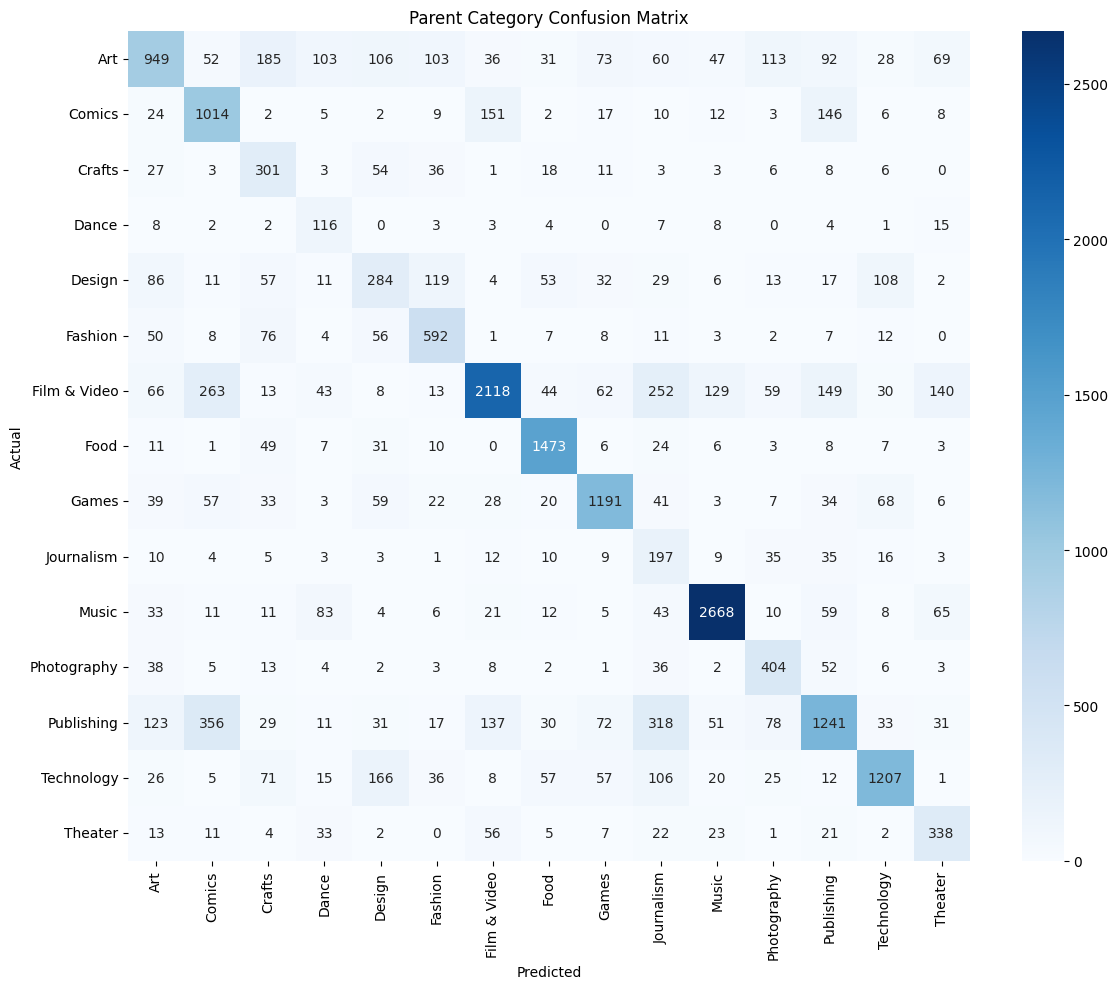

In [ ]:
# Compute confusion matrix
parent_cm = confusion_matrix(
    test_df['category.parent_name'],
    test_df['predicted_parent']
)

# Get sorted labels for consistent axis ordering
parent_labels = sorted(test_df['category.parent_name'].unique())

plt.figure(figsize=(12, 10))
sns.heatmap(
    parent_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=parent_labels,
    yticklabels=parent_labels
)

plt.title("Parent Category Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


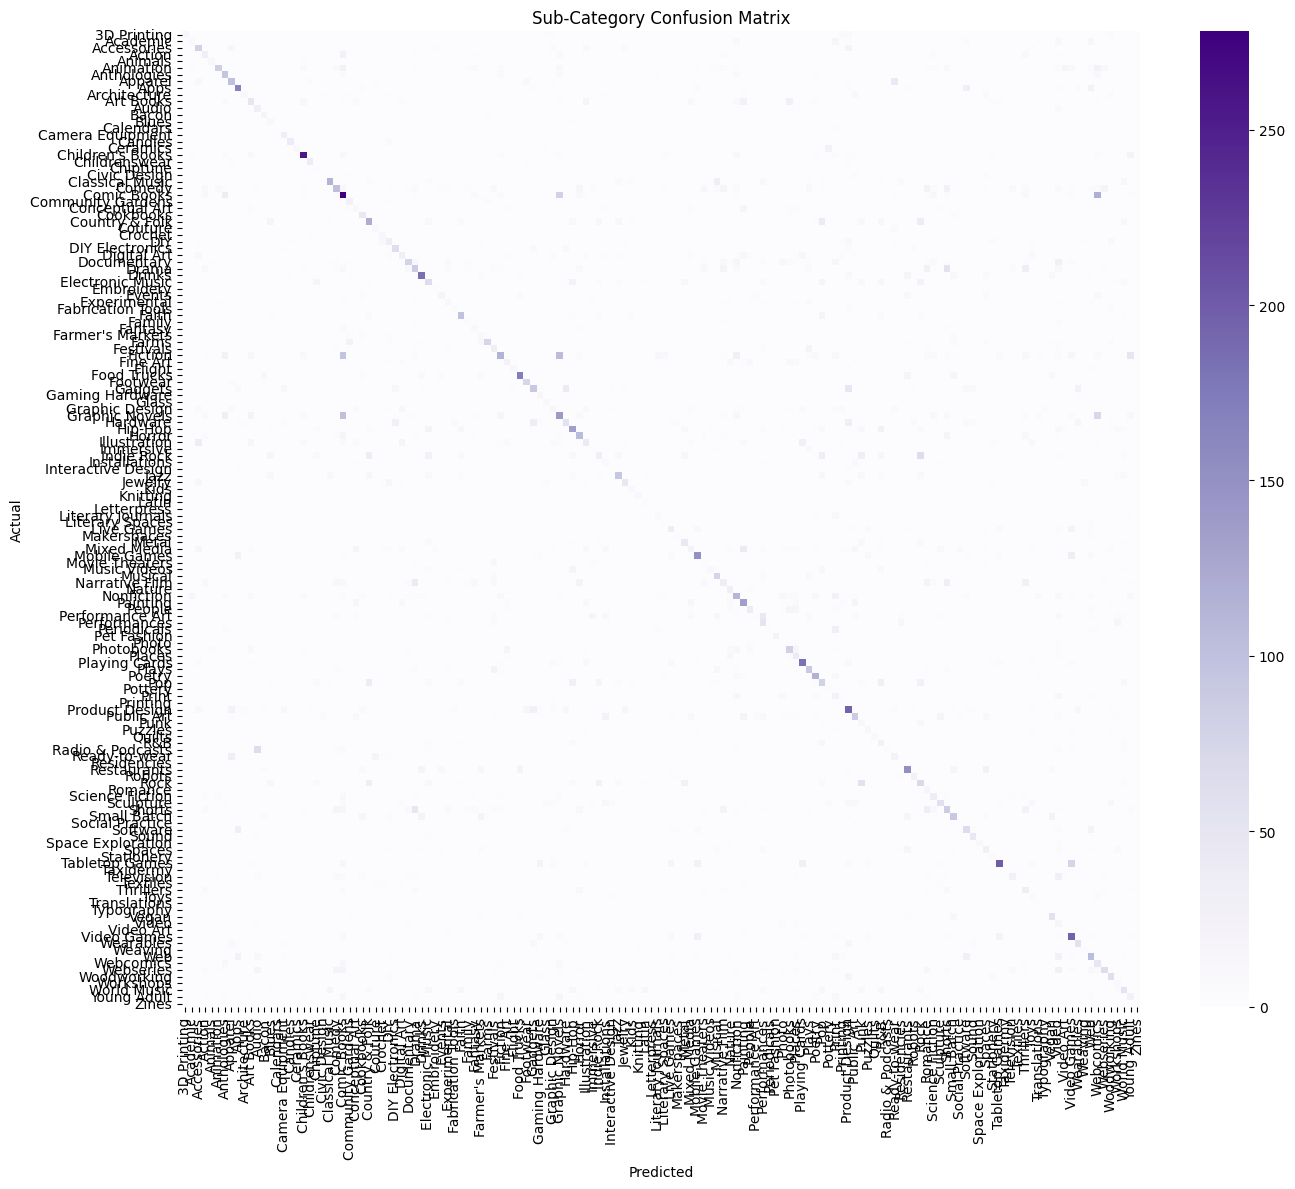

In [55]:
child_cm = confusion_matrix(
    test_df['category.name'],
    test_df['predicted_child']
)

child_labels = sorted(test_df['category.name'].unique())

plt.figure(figsize=(14, 12))
sns.heatmap(
    child_cm,
    annot=False,   # Turn on if you want numbers, but large matrices get cluttered
    cmap='Purples',
    xticklabels=child_labels,
    yticklabels=child_labels
)

plt.title("Sub‑Category Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
